In [21]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Vizualización de los datos, en el parentesis podemos poner cualquier numero de preferenica 10 para mostarar mas filas, pero en este caso solo es visualización.
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Inspección de integridad: Revisamos dimensiones, tipos de datos y nulos iniciales.
print(f"Dimensiones del dataset: {df.shape}")
print("\nConteo de valores nulos por columna:")
print(df.isnull().sum())

print(f"\nRegistros duplicados detectados: {df.duplicated().sum()}")

Dimensiones del dataset: (891, 15)

Conteo de valores nulos por columna:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Registros duplicados detectados: 107


Limpieza e Imputación.

In [23]:
#Hacemos una copia para no dañar la base original.
df_clean = df.copy()

# Elimina duplicados.
df_clean = df_clean.drop_duplicates()

# Revisa porcentaje de nulos y calcula el porcentaje de valores faltantes por columna.
null_pct = df_clean.isnull().mean() * 100
print(null_pct.sort_values(ascending=False))

# Eliminar columnas con demasiados faltantes o redundantes.
# deck suele tener demasiados faltantes.
# alive es redundante con survived.
df_clean = df_clean.drop(columns=["deck", "alive"], errors="ignore")

deck           74.234694
age            13.520408
embarked        0.255102
embark_town     0.255102
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64


In [24]:
# Agrupamos columnas por el tipo de tratamiento que requieren.
cols_mediana = ["age", "fare"]
cols_moda = ["embarked", "embark_town", "who"]

# Esto hace el código escalable: si mañana hay 10 columnas más, solo las agregas a la lista arriba.
for col in cols_mediana:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cols_moda:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verificación final de limpieza.
print("Conteo de nulos después de la imputación:")
print(df_clean.isnull().sum())


Conteo de nulos después de la imputación:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64


Estadísticas de tendencia central

In [25]:
# Separamos las columnas por tipo para a un nálisis descriptivo.
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

resumen_numericas = pd.DataFrame({
    "media": df_clean[num_cols].mean(),
    "mediana": df_clean[num_cols].median(),
    "moda": df_clean[num_cols].mode().iloc[0],
    "min": df_clean[num_cols].min(),
    "max": df_clean[num_cols].max(),
    "std": df_clean[num_cols].std()
})

# Un resumen para variables categóricas.
resumen_categoricas = pd.DataFrame({
    "moda": df_clean[cat_cols].mode().iloc[0],
    "frecuencia_moda": [df_clean[col].value_counts().iloc[0] for col in cat_cols],
    "n_unicos": [df_clean[col].nunique() for col in cat_cols]
})

# Tasa de supervivencia media por grupos.
tasa_sexo = df_clean.groupby('sex')['survived'].mean()
tasa_clase = df_clean.groupby('class')['survived'].mean()

print("\nResumen Estadístico Numérico:\n", resumen_numericas)
print("\nTasa de supervivencia por Sexo:\n", tasa_sexo)


Resumen Estadístico Numérico:
               media  mediana   moda   min       max        std
survived   0.411990     0.00   0.00  0.00    1.0000   0.492507
pclass     2.243622     3.00   3.00  1.00    3.0000   0.855056
age       29.650408    28.25  28.25  0.42   80.0000  13.734925
sibsp      0.522959     0.00   0.00  0.00    8.0000   0.986231
parch      0.415816     0.00   0.00  0.00    6.0000   0.836922
fare      34.711740    15.90  13.00  0.00  512.3292  52.160151

Tasa de supervivencia por Sexo:
 sex
female    0.740614
male      0.215886
Name: survived, dtype: float64


Graficas de variables por categoria

C:\Users\Emiliano\AppData\Local\Temp\ipykernel_22664\3772844878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette="viridis")


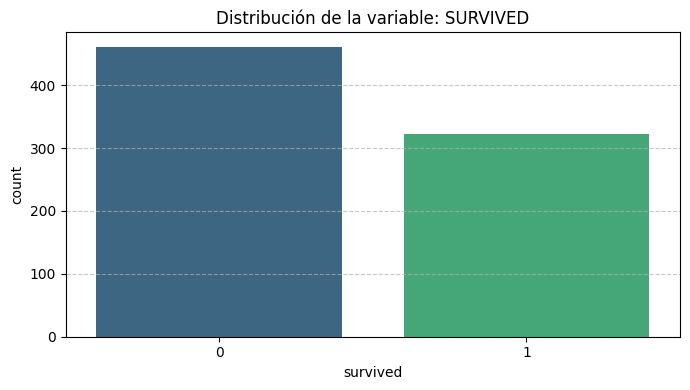

C:\Users\Emiliano\AppData\Local\Temp\ipykernel_22664\3772844878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette="viridis")


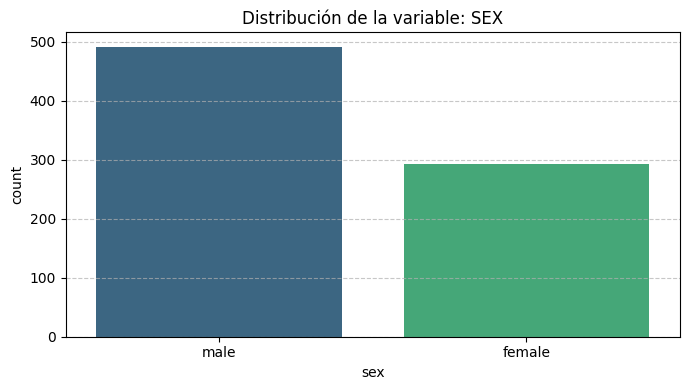

C:\Users\Emiliano\AppData\Local\Temp\ipykernel_22664\3772844878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette="viridis")


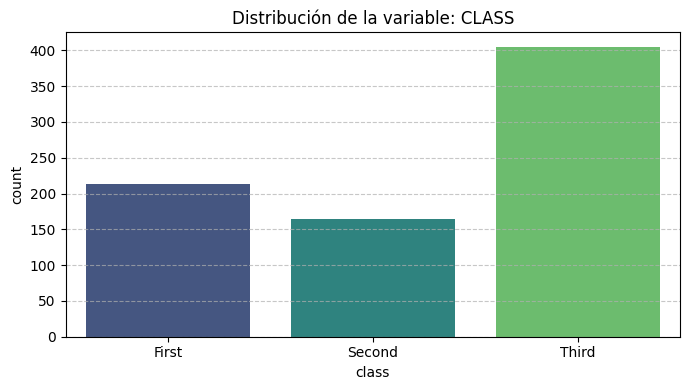

C:\Users\Emiliano\AppData\Local\Temp\ipykernel_22664\3772844878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette="viridis")


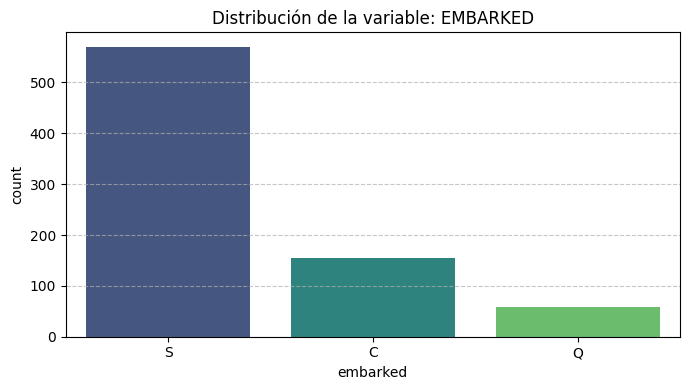

C:\Users\Emiliano\AppData\Local\Temp\ipykernel_22664\3772844878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette="viridis")


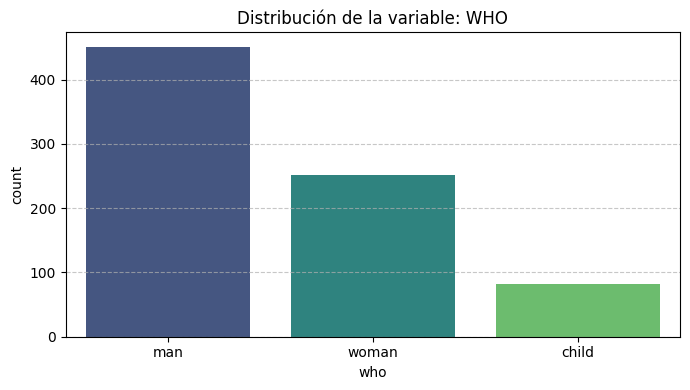

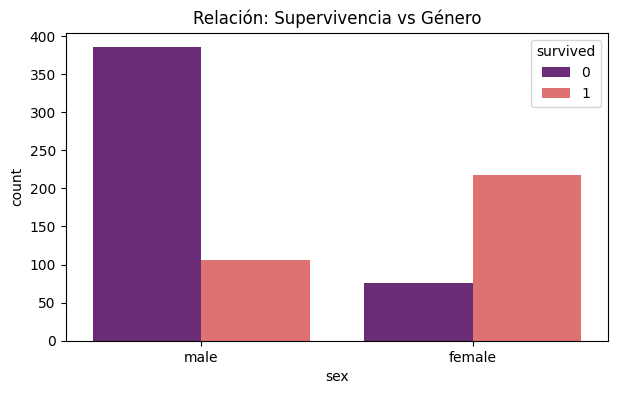

In [26]:
# Visualización univariada de variables categóricas.
categoricas_graficar = ["survived", "sex", "class", "embarked", "who"]

for col in categoricas_graficar:
    if col in df_clean.columns:
        plt.figure(figsize=(7,4))
        sns.countplot(data=df_clean, x=col, palette="viridis")
        plt.title(f"Distribución de la variable: {col.upper()}")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

# Visualización Relación Sexo vs Supervivencia.
plt.figure(figsize=(7,4))
sns.countplot(data=df_clean, x="sex", hue="survived", palette="magma")
plt.title("Relación: Supervivencia vs Género")
plt.show()

Matriz de correlación

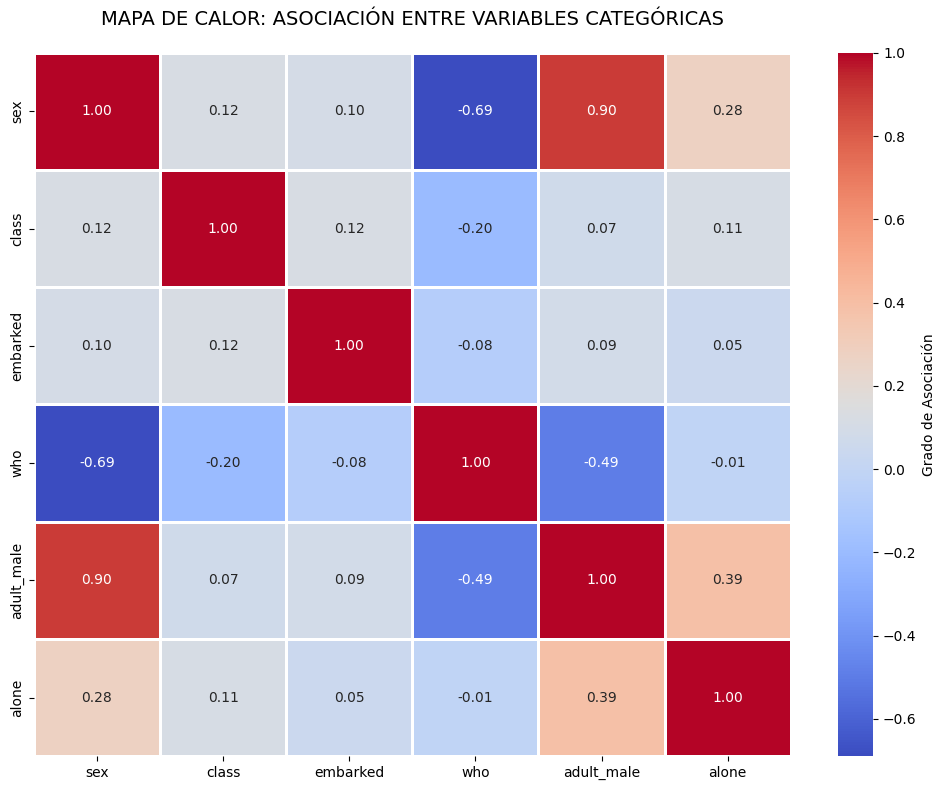


Matriz de Correlación de Spearman:
                  sex     class  embarked       who  adult_male     alone
sex         1.000000  0.120144  0.100920 -0.689778    0.898999  0.280460
class       0.120144  1.000000  0.116002 -0.202537    0.072709  0.111637
embarked    0.100920  0.116002  1.000000 -0.075138    0.085397  0.048502
who        -0.689778 -0.202537 -0.075138  1.000000   -0.493352 -0.013270
adult_male  0.898999  0.072709  0.085397 -0.493352    1.000000  0.387850
alone       0.280460  0.111637  0.048502 -0.013270    0.387850  1.000000


In [27]:
from sklearn.preprocessing import LabelEncoder
#Aislamiento de de variables críticas para el análisis de supervivencia.
cat_df = df_clean[["sex", "class", "embarked", "who", "adult_male", "alone"]].copy()

# Transformamnod de categorías a dominios numéricos (Label Encoding).
for col in cat_df.columns:
    cat_df[col] = cat_df[col].astype(str)
    le = LabelEncoder()
    cat_df[col] = le.fit_transform(cat_df[col])

#Cálculo de matriz de asociación y visualización.
corr_cat = cat_df.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_cat, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            linewidths=0.8, 
            cbar_kws={'label': 'Grado de Asociación'})

plt.title("MAPA DE CALOR: ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Imprimimos la matriz para tener el respaldo numérico exacto
print("\nMatriz de Correlación de Spearman:\n", corr_cat)

In [28]:
df_clean.to_csv("titanic_limpio.csv", index=False)
resumen_numericas.to_excel("resumen_numericas.xlsx")
resumen_categoricas.to_excel("resumen_categoricas.xlsx")
corr_cat.to_excel("matriz_asociacion_categoricas.xlsx")

In [30]:
tasa_supervivencia = df_clean['survived'].mean() * 100

conclusiones = f"""
CONCLUSIONES DEL ANÁLISIS - TITANIC

TRATAMIENTO DE DATOS:
- Se eliminaron duplicados y las columnas 'deck' (por tener 77% de nulos) y 'alive' (redundante).
- Se imputó la edad con la mediana y el puerto de embarque con la moda para asegurar una base completa.

HALLAZGOS ESTADÍSTICOS:
- La tasa de supervivencia general fue del {tasa_supervivencia:.2f}%.
- Las mujeres y los pasajeros de primera clase presentan las mayores probabilidades de supervivencia.

ANÁLISIS DE CORRELACIÓN:
- La matriz de Spearman confirma que el género ('sex') es el predictor más influyente en el modelo.
- Existe una correlación negativa fuerte en la variable 'adult_male', validando la prioridad de evacuación.

METODOLOGÍA:
- El uso de Python y sus librerías (Pandas, Seaborn) permitió transformar datos crudos en información accionable de manera eficiente.
"""

with open("conclusiones.txt", "w") as f:
    f.write(conclusiones)

print("Archivo conclusiones.txt generado.")

Archivo conclusiones.txt generado.
